# 06 - Monte Carlo Sensitivity Analysis

CRED Market Entry and Segmentation Diagnostic - Shashank Tiwari, IIT Kharagpur

In [1]:
import sys, warnings, logging
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
import config
from src.utils import setup_logging
setup_logging(logging.INFO)
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)
FIG = config.FIGURES_DIR

Three robustness checks: (1) 1,000 runs jittering the dedup thresholds by +/-5%, (2) 100 bootstrap re-clusterings, (3) 100 bootstrap XGBoost refits. The full runs execute inside `run_pipeline.py`; this notebook reloads the run logs and re-runs a small demo.

In [2]:
mc = pd.read_csv(config.REPORTS_DIR / 'monte_carlo_summary.csv')
mc

,analysis,runs,baseline_sample_holders,scale_factor,mean_M,std_M,median_M,ci95_low_M,ci95_high_M,min_M,max_M,mean,std,min,max,ci95_low,ci95_high
0,dedup_holder_count,1000,47236.0,804.471166,37.797041,1.138578,37.963397,35.650924,39.44662,35.318698,39.686976,NaN,NaN,NaN,NaN,NaN,NaN
1,cluster_stability_jaccard,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.997437,0.022862,0.771104,1.0,NaN,NaN
2,propensity_auc,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.828002,0.002809,NaN,NaN,0.823101,0.833247


In [3]:
dedup = pd.read_csv(config.REPORTS_DIR / 'mc_dedup_runs.csv')
dedup.describe().round(3)

,min_credit_score,min_monthly_spend,min_repayment_pct,sample_holders,market_holders_M
count,1000.000,1000.000,1000.000,1000.000,1000.000
mean,599.831,2001.699,0.150,46983.711,37.797
std,17.495,57.869,0.004,1415.312,1.139
min,570.074,1900.104,0.143,43903.000,35.319
25%,584.416,1949.901,0.146,45804.500,36.848
50%,599.689,1999.301,0.150,47190.500,37.963
75%,615.534,2052.611,0.154,48220.750,38.792
max,629.946,2099.884,0.157,49333.000,39.687


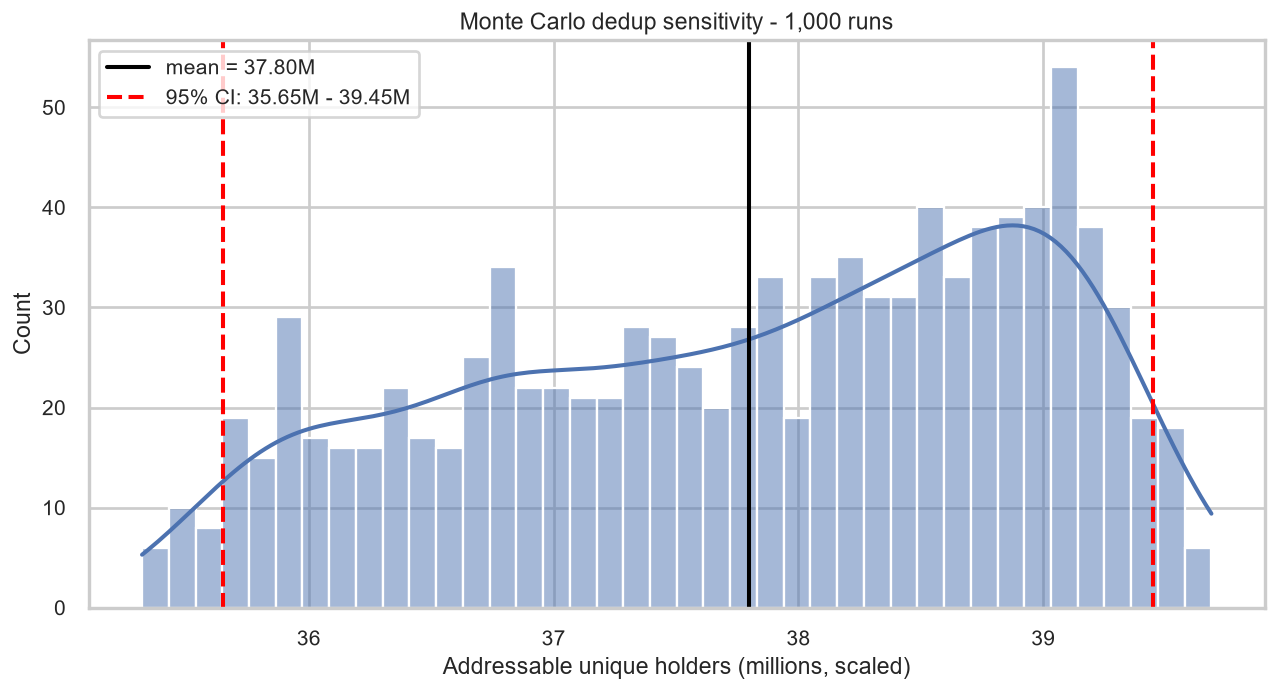

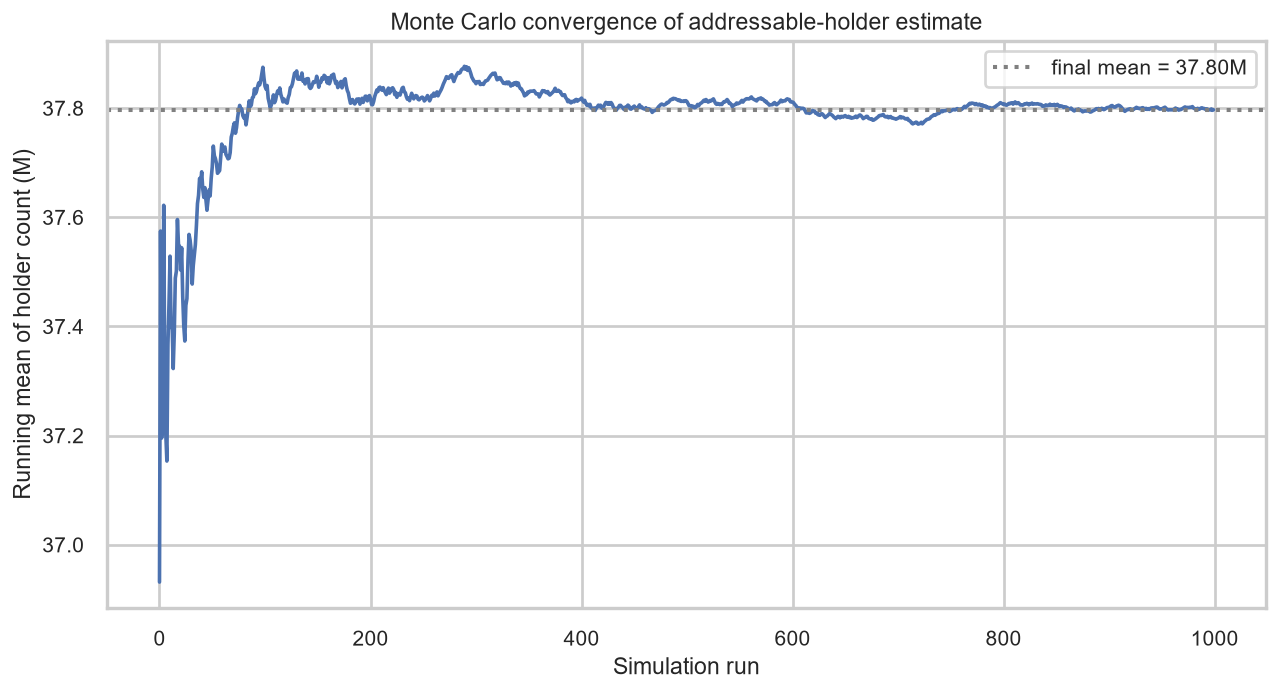

In [4]:
display(Image(FIG / 'mc_holder_count_dist.png', width=800)); display(Image(FIG / 'mc_convergence.png', width=800))

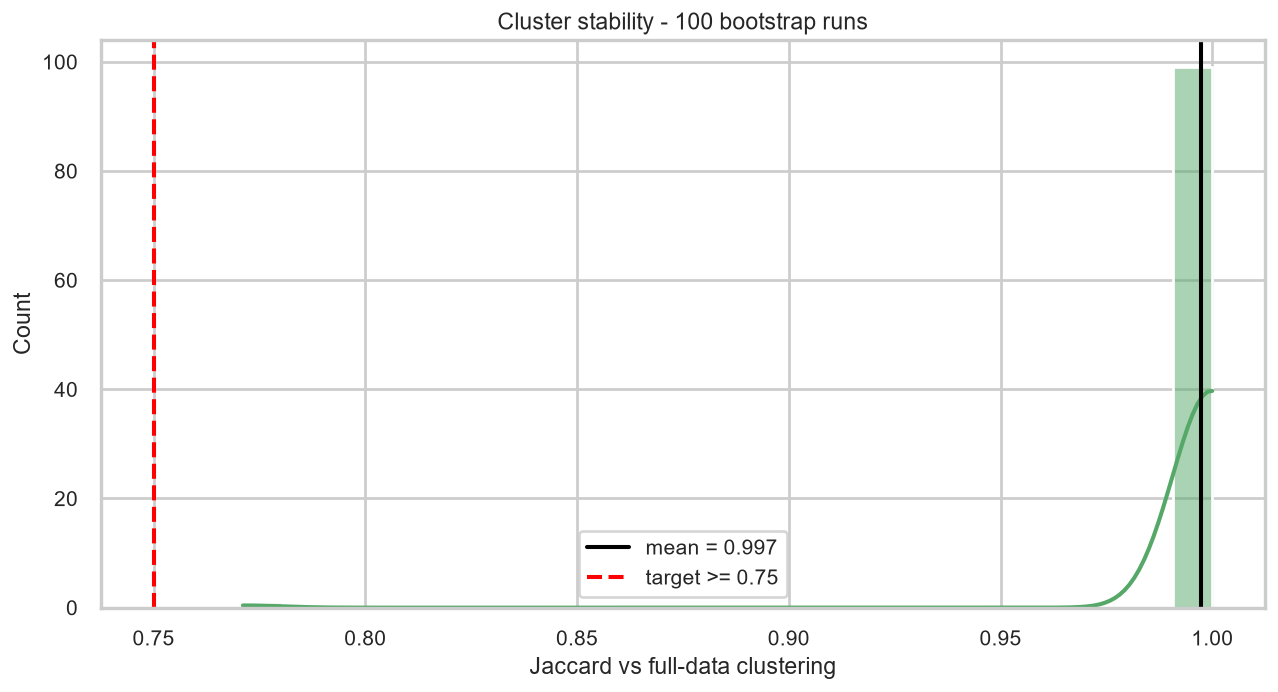

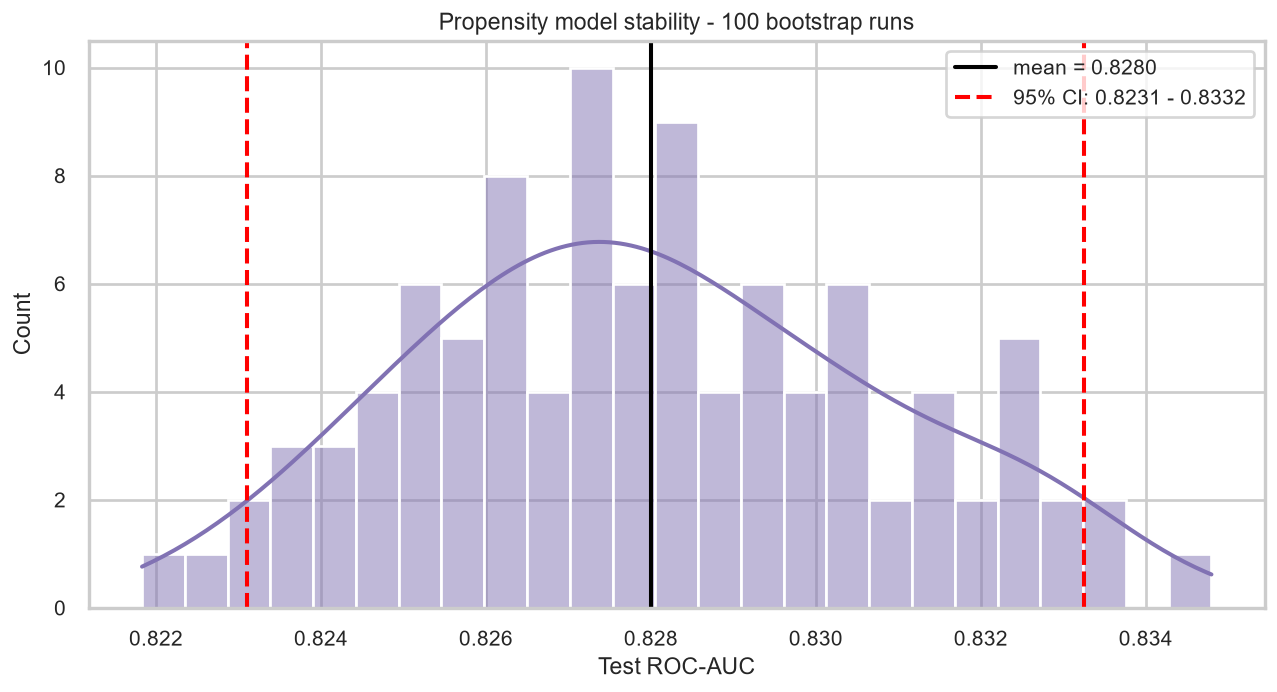

In [5]:
display(Image(FIG / 'mc_jaccard_dist.png', width=800)); display(Image(FIG / 'mc_auc_dist.png', width=800))

### Small live demo (50 dedup runs)

In [6]:
from src.data_generator import load_raw
from src.preprocessing import clean_data
from src.monte_carlo import run_dedup_sensitivity
cards, _ = load_raw(panel=False)
clean, _ = clean_data(cards)
demo = run_dedup_sensitivity(clean, n_runs=50)
demo['summary']

04:59:31 | INFO    | cred.preprocessing | Cleaning: 200,000 -> 195,000 rows | purity = 97.50% (target >= 92%)


04:59:31 | INFO    | cred.preprocessing |   dropped: score=2000 income=1500 nulls=1500 | imputed: age, gender, city, annual_income_lakhs, card_type, card_issuer, months_active, upi_credit_usage, reward_redemption_rate, digital_transaction_pct


05:00:04 | INFO    | cred.monte_carlo | Dedup MC (50 runs): mean 37.70M | 95% CI 35.56M - 39.32M | std 1.13M


{'runs': 50,
 'baseline_sample_holders': 47236,
 'scale_factor': 804.4711660597849,
 'mean_M': 37.702651367600986,
 'std_M': 1.1285316124070268,
 'median_M': 37.88093826742315,
 'ci95_low_M': 35.56476522144127,
 'ci95_high_M': 39.324320433567614,
 'min_M': 35.49165890422559,
 'max_M': 39.38529934795495}